# 🔬 Deep Learning Compiler Verification — NVIDIA Senior Engineer Role

**Focus:** DL compiler verification, functional & performance testing, regression detection  
**Frameworks:** PyTorch, JAX/XLA, TensorRT  
**Role:** Senior Engineer — Deep Learning Compiler Verification & Infrastructure

## What this role does
NVIDIA's DL compiler stack takes neural network operations written in PyTorch or JAX
and compiles them into optimized GPU kernels. Your job is to make sure:

1. **Correctness** — compiled models produce numerically equivalent output to eager execution
2. **Performance** — compiled kernels are faster than eager; regressions are caught
3. **Coverage** — every supported op, dtype, and backend is tested systematically
4. **Infrastructure** — the verification pipelines themselves are reliable and maintainable

| What you verify | Why it's hard |
|---|---|
| Numerical equivalence | Compiler may reorder ops; floating point is not associative |
| dtype correctness | fp16/bf16 have lower precision; overflow/underflow differ |
| Backend parity | `torch.compile` with `inductor` vs `cudagraphs` vs `TensorRT` |
| Performance regression | A fusion change can help one op and break another |
| Edge cases | Zero tensors, NaN propagation, extreme shapes |

---

In this notebook you will:
1. Understand **what a DL compiler does** and the major compiler stacks
2. Learn **test planning** for DL ops with numerical tolerances and dtype coverage
3. Build a **functional verification framework** testing eager vs compiled equivalence
4. **Benchmark GPU kernels** with `torch.cuda.Event` and collect reliable statistics
5. Apply **statistical regression detection** to compiler performance data
6. Complete **3 challenges** that reflect real senior engineer work at NVIDIA

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import time
import warnings
import math
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Callable, Tuple

warnings.filterwarnings('ignore', category=torch.jit.TracerWarning)
warnings.filterwarnings('ignore', message='.*TorchDynamo.*')

print("✅ Imports OK")
print(f"   PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.version.cuda}")
print(f"   GPU      : {torch.cuda.get_device_name(0)}")
print(f"   cuDNN    : {torch.backends.cudnn.version()}")
DEVICE = torch.device('cuda')

✅ Imports OK
   PyTorch  : 2.10.0+cu128
   CUDA     : 12.8
   GPU      : NVIDIA GeForce RTX 4070 SUPER
   cuDNN    : 91002


## 1. What a Deep Learning Compiler Does

### Eager execution vs compiled execution

In **eager mode** (default PyTorch), every op dispatches to a separate GPU kernel immediately:
```
x = torch.relu(x)      # kernel launch 1
x = x + bias           # kernel launch 2
x = torch.relu(x)      # kernel launch 3
```
Each launch has overhead and intermediate tensors are written to / read from VRAM.

A **DL compiler** analyzes the computation graph and can:
- **Fuse** ops (relu + add + relu → one kernel, data stays in registers)
- **Eliminate** redundant memory traffic
- **Tile** matrix multiplications for Tensor Core alignment
- **Select** the fastest cuBLAS / cuDNN algorithm for the given shapes

### The major DL compiler stacks on NVIDIA GPUs

```
┌─────────────────────────────────────────────────────────────────┐
│                     PyTorch / JAX (user code)                   │
└──────────────┬──────────────────┬──────────────────┬────────────┘
               │                  │                  │
        torch.compile           JAX jit           TensorRT
               │                  │                  │
        TorchDynamo           XLA/HLO          TRT Engine
        (trace graph)       (StableHLO)       (layer fusion)
               │                  │                  │
        TorchInductor         NVPTX JIT        cuDNN / cuBLAS
        (triton codegen)    (LLVM backend)     (hand-tuned)
               │                  │                  │
               └──────────────────┴──────────────────┘
                                  │
                         PTX / SASS (GPU ISA)
                                  │
                         NVIDIA GPU Hardware
```

### torch.compile pipeline (PyTorch 2.x)

```
Python function
      │
      ▼  TorchDynamo
  FX Graph (symbolic trace of Python bytecode)
      │
      ▼  AOTAutograd (optional, for training)
  Joint forward+backward graph
      │
      ▼  TorchInductor (default backend)
  Triton kernel source code (auto-generated)
      │
      ▼  Triton compiler
  PTX / SASS running on the GPU
```

### What a verification engineer must test at each stage

| Stage | Failure mode | How to catch it |
|---|---|---|
| Graph capture | Ops not captured, graph breaks | Check captured graph structure |
| Numerical | Compiled output ≠ eager output | `torch.allclose` with tolerance |
| dtype handling | fp16 overflow, bf16 rounding | Test all dtypes explicitly |
| Edge cases | NaN/inf propagation changes | Zero tensors, extreme values |
| Performance | Compiled slower than eager | CUDA event benchmarks, P95 |
| Backend parity | `inductor` OK but `cudagraphs` wrong | Test each backend separately |

## 2. DL Framework Landscape

### PyTorch eager vs torch.compile

```python
# Eager — op-by-op, immediate execution
def model_eager(x, w):
    return torch.relu(x @ w)

# Compiled — graph is traced, fused, and cached
model_compiled = torch.compile(model_eager)   # PyTorch 2.0+
# First call: compiles (slow)
# Subsequent calls: runs the compiled kernel (fast)
```

### JAX jit

```python
import jax
import jax.numpy as jnp

def model(x, w):
    return jnp.maximum(x @ w, 0)      # relu via maximum

model_jit = jax.jit(model)             # traces on first call → XLA HLO
# XLA compiles the HLO graph to PTX/SASS for the GPU
```

### TensorRT

```python
# TensorRT: serialize a PyTorch model to a TRT engine
# torch_tensorrt.compile() parses the TorchScript/FX graph
# and builds a highly-optimized TRT engine (ahead of time)
import torch_tensorrt
trt_model = torch_tensorrt.compile(model, inputs=[example_input],
                                   enabled_precisions={torch.float16})
```

### Comparison table

| Feature | PyTorch Eager | torch.compile | JAX jit | TensorRT |
|---|---|---|---|---|
| Compilation | None (JIT per op) | JIT (first call) | JIT (first call) | AOT (offline) |
| Graph capture | None | TorchDynamo | JAX tracing | TorchScript/ONNX |
| Backend | cuDNN/cuBLAS | TorchInductor | XLA | TRT engine |
| Training support | ✅ | ✅ | ✅ | ❌ (inference only) |
| Dynamic shapes | ✅ | Partial | Recompiles | Partial |
| Typical speedup | baseline | 1.5–3× | 1.5–4× | 2–6× |
| Verification challenge | None | Numerical match | Numerical match | Numerical match + precision |

In [14]:
# ── Demonstrate eager vs torch.compile on a simple workload ──────────────────
# We use a small MLP to show the compilation workflow.

class SmallMLP(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 4)
        self.fc2 = nn.Linear(dim * 4, dim)
        self.act = nn.GELU()

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

model_eager = SmallMLP(dim=512).cuda().eval()
x = torch.randn(32, 512, device=DEVICE)

# Compile the model
model_compiled = torch.compile(model_eager, mode='default')

# Trigger compilation (first call is slow — this is expected)
with torch.no_grad():
    out_eager    = model_eager(x)
    out_compiled = model_compiled(x)   # compiles here

# Verify numerical equivalence
match = torch.allclose(out_eager, out_compiled, atol=1e-4, rtol=1e-4)
max_diff = (out_eager - out_compiled).abs().max().item()

print(f"Eager output shape    : {out_eager.shape}")
print(f"Compiled output shape : {out_compiled.shape}")
print(f"Outputs match         : {'✅' if match else '❌'} (max diff = {max_diff:.2e})")
print()
print("Note: torch.compile uses the 'inductor' backend by default,")
print("which generates Triton kernels that fuse ops for the specific input shape.")

Eager output shape    : torch.Size([32, 512])
Compiled output shape : torch.Size([32, 512])
Outputs match         : ✅ (max diff = 2.68e-07)

Note: torch.compile uses the 'inductor' backend by default,
which generates Triton kernels that fuse ops for the specific input shape.


## 3. Verification Planning

Before writing a single test, a verification engineer writes a **verification plan** —
what will be tested, under what conditions, and what counts as passing.

### Key concepts specific to DL compiler verification

**Numerical tolerance** — compiled results are not bit-identical to eager:
```
Eager:    matmul(A, B)  →  accumulates in fp32 in a specific order
Compiled: fused kernel  →  may reorder accumulations for parallelism

Result: differences of ~1e-5 are normal and acceptable.
Result: differences of ~1e-2 signal a real bug.
```

**dtype-specific tolerances:**
| dtype | Typical atol | Typical rtol | Notes |
|---|---|---|---|
| float32 | 1e-5 | 1e-5 | Most precise |
| float16 | 1e-2 | 1e-3 | 10-bit mantissa, limited range |
| bfloat16 | 1e-2 | 1e-2 | 7-bit mantissa, same range as fp32 |

**Backend** — the same op compiled with `inductor` vs `cudagraphs` vs `tensorrt`
may produce slightly different results and must be tested independently.

**Priority levels:**
- **P0** — blocker: output is wrong for the common case, release cannot ship
- **P1** — high: wrong for an important edge case or specific dtype
- **P2** — medium: wrong for a rare configuration
- **P3** — low: cosmetic or documentation issue

In [15]:
# ── Verification planning dataclasses for DL compiler testing ─────────────────

@dataclass
class DLTestCase:
    id: str
    description: str
    category: str          # functional / edge / regression / performance / dtype
    op_name: str           # e.g. 'torch.matmul', 'F.scaled_dot_product_attention'
    dtype: torch.dtype     # dtype under test
    backend: str           # 'eager', 'inductor', 'cudagraphs', 'tensorrt'
    atol: float            # absolute tolerance for torch.allclose
    rtol: float            # relative tolerance for torch.allclose
    priority: str = 'P1'
    notes: str = ''

@dataclass
class DLVerificationPlan:
    name: str
    component: str         # e.g. 'torch.compile / inductor', 'TensorRT'
    owner: str
    cases: List[DLTestCase] = field(default_factory=list)

    def summary(self):
        cats    = {}
        dtypes  = {}
        backends = {}
        for c in self.cases:
            cats[c.category]          = cats.get(c.category, 0) + 1
            dtypes[str(c.dtype)]      = dtypes.get(str(c.dtype), 0) + 1
            backends[c.backend]       = backends.get(c.backend, 0) + 1
        print(f"Verification Plan : {self.name}")
        print(f"Component         : {self.component}")
        print(f"Owner             : {self.owner}")
        print(f"Total cases       : {len(self.cases)}")
        print()
        print("  By category:")
        for k, v in sorted(cats.items()):
            print(f"    {k:15s}: {v}")
        print("  By dtype:")
        for k, v in sorted(dtypes.items()):
            print(f"    {k:30s}: {v}")
        print("  By backend:")
        for k, v in sorted(backends.items()):
            print(f"    {k:15s}: {v}")


# Example: verification plan for torch.matmul through torch.compile
matmul_plan = DLVerificationPlan(
    name="torch.matmul — compile correctness",
    component="torch.compile / TorchInductor",
    owner="dl-compiler-verification",
    cases=[
        DLTestCase("TC001", "fp32 matmul, square matrices",
                   "functional", "torch.matmul", torch.float32, "inductor", 1e-5, 1e-5),
        DLTestCase("TC002", "fp16 matmul — Tensor Core path",
                   "dtype",      "torch.matmul", torch.float16, "inductor", 1e-2, 1e-3),
        DLTestCase("TC003", "bf16 matmul — reduced mantissa",
                   "dtype",      "torch.matmul", torch.bfloat16, "inductor", 1e-2, 1e-2),
        DLTestCase("TC004", "matmul with zero matrix (left)",
                   "edge",       "torch.matmul", torch.float32, "inductor", 0.0, 0.0,
                   "P1", "Result must be exactly zero"),
        DLTestCase("TC005", "matmul with zero matrix (right)",
                   "edge",       "torch.matmul", torch.float32, "inductor", 0.0, 0.0,
                   "P1", "Result must be exactly zero"),
        DLTestCase("TC006", "matmul — very large values near fp16 max",
                   "edge",       "torch.matmul", torch.float16, "inductor", 1e-1, 1e-1,
                   "P1", "fp16 max ~65504; check for overflow"),
        DLTestCase("TC007", "matmul — NaN in input propagates to output",
                   "edge",       "torch.matmul", torch.float32, "inductor", 0.0, 0.0,
                   "P0", "NaN propagation must match eager exactly"),
        DLTestCase("TC008", "regression: issue #7821 — fp16 matmul shape (M=1)",
                   "regression", "torch.matmul", torch.float16, "inductor", 1e-2, 1e-3,
                   "P0", "Vector-matrix case was wrong in inductor v2.1"),
        DLTestCase("TC009", "fp32 matmul, cudagraphs backend",
                   "functional", "torch.matmul", torch.float32, "cudagraphs", 1e-5, 1e-5),
        DLTestCase("TC010", "non-square matrices (M=128, K=256, N=64)",
                   "functional", "torch.matmul", torch.float32, "inductor", 1e-5, 1e-5),
    ]
)

matmul_plan.summary()

Verification Plan : torch.matmul — compile correctness
Component         : torch.compile / TorchInductor
Owner             : dl-compiler-verification
Total cases       : 10

  By category:
    dtype          : 2
    edge           : 4
    functional     : 3
    regression     : 1
  By dtype:
    torch.bfloat16                : 1
    torch.float16                 : 3
    torch.float32                 : 6
  By backend:
    cudagraphs     : 1
    inductor       : 9


## 4. Functional Verification — Correctness Testing

Functional verification answers: **does the compiled op produce the same answer as eager?**

### The verification workflow

```
Input tensors (same data, same dtype)
          │
     ┌────┴────┐
     ▼         ▼
   Eager    Compiled
   output    output
     │         │
     └────┬────┘
          ▼
    torch.allclose(eager, compiled, atol=..., rtol=...)
          │
       ✅ pass  or  ❌ fail → report max diff, shape, dtype
```

### torch.allclose formula
```
|eager - compiled| ≤ atol + rtol * |compiled|
```
This is a *relative + absolute* check — important for values that span many magnitudes.

### Why test multiple dtypes?
The compiler may use different code paths for fp32 vs fp16:
- fp32: standard CUDA cores, full precision accumulation
- fp16: Tensor Cores (8×8×4 matrix units), faster but lower precision
- bf16: Tensor Cores, wider dynamic range than fp16 (same exponent bits as fp32)

A bug in the fp16 Tensor Core path would only show up in fp16 tests.

In [16]:
# ── Functional verification framework ────────────────────────────────────────

@dataclass
class VerificationResult:
    test_id: str
    description: str
    passed: bool
    max_abs_diff: float
    max_rel_diff: float
    atol: float
    rtol: float
    dtype: str
    backend: str
    note: str = ''


def verify_compiled_op(
    test_id: str,
    description: str,
    eager_fn: Callable,
    inputs: List[torch.Tensor],
    atol: float,
    rtol: float,
    backend: str = 'inductor',
    verbose: bool = True,
) -> VerificationResult:
    """
    Compare eager vs torch.compile output for a given function and inputs.
    Returns a VerificationResult with pass/fail and diff statistics.
    """
    dtype_str = str(inputs[0].dtype)

    compiled_fn = torch.compile(eager_fn, backend=backend, fullgraph=False)

    with torch.no_grad():
        out_eager    = eager_fn(*inputs)
        out_compiled = compiled_fn(*inputs)

    # Handle NaN: if eager has NaN, check compiled does too in the same positions
    eager_nan    = torch.isnan(out_eager)
    compiled_nan = torch.isnan(out_compiled)
    nan_match    = torch.equal(eager_nan, compiled_nan)

    # Compute diffs on non-NaN elements
    mask = ~eager_nan
    if mask.any():
        abs_diff = (out_eager[mask] - out_compiled[mask]).abs()
        max_abs  = abs_diff.max().item()
        # relative diff: |diff| / (|compiled| + epsilon)
        rel_diff = abs_diff / (out_compiled[mask].abs() + 1e-8)
        max_rel  = rel_diff.max().item()
    else:
        max_abs = max_rel = 0.0

    passed = torch.allclose(out_eager, out_compiled, atol=atol, rtol=rtol,
                             equal_nan=True)

    note = ''
    if not nan_match:
        note = 'NaN positions differ!'
        passed = False

    result = VerificationResult(
        test_id=test_id, description=description,
        passed=passed, max_abs_diff=max_abs, max_rel_diff=max_rel,
        atol=atol, rtol=rtol, dtype=dtype_str, backend=backend, note=note
    )

    if verbose:
        icon = '✅' if passed else '❌'
        print(f"  {icon} [{test_id}] {description}")
        print(f"       dtype={dtype_str}  backend={backend}  "
              f"max_abs={max_abs:.2e}  max_rel={max_rel:.2e}  "
              f"(tol: atol={atol:.0e}, rtol={rtol:.0e})"
              + (f"  ⚠ {note}" if note else ''))

    return result


# ── Test suite: torch.matmul across dtypes ────────────────────────────────────
torch.manual_seed(42)
M, K, N = 128, 256, 128

def matmul_fn(a, b):
    return torch.matmul(a, b)

print("Functional verification — torch.matmul")
print("─" * 70)

results = []

# fp32
a32 = torch.randn(M, K, device=DEVICE, dtype=torch.float32)
b32 = torch.randn(K, N, device=DEVICE, dtype=torch.float32)
results.append(verify_compiled_op("TC001", "fp32 matmul", matmul_fn, [a32, b32], 1e-4, 1e-4))

# fp16
a16 = a32.half()
b16 = b32.half()
results.append(verify_compiled_op("TC002", "fp16 matmul", matmul_fn, [a16, b16], 1e-2, 1e-3))

# bf16
abf = a32.bfloat16()
bbf = b32.bfloat16()
results.append(verify_compiled_op("TC003", "bf16 matmul", matmul_fn, [abf, bbf], 1e-1, 1e-2))

# Edge: zero matrix
a_zero = torch.zeros(M, K, device=DEVICE, dtype=torch.float32)
results.append(verify_compiled_op("TC004", "zero matrix (left operand)", matmul_fn,
                                   [a_zero, b32], atol=0.0, rtol=0.0))

# Edge: NaN in input
a_nan = a32.clone()
a_nan[0, 0] = float('nan')
results.append(verify_compiled_op("TC005", "NaN propagation", matmul_fn, [a_nan, b32],
                                   atol=1e-4, rtol=1e-4))

# Edge: vector-matrix (M=1)
a_vec = torch.randn(1, K, device=DEVICE, dtype=torch.float16)
results.append(verify_compiled_op("TC006", "fp16 vector-matrix (M=1)", matmul_fn,
                                   [a_vec, b16], atol=1e-2, rtol=1e-3))

passed_count = sum(1 for r in results if r.passed)
print(f"\nResults: {passed_count}/{len(results)} passed")

Functional verification — torch.matmul
──────────────────────────────────────────────────────────────────────
  ✅ [TC001] fp32 matmul
       dtype=torch.float32  backend=inductor  max_abs=0.00e+00  max_rel=0.00e+00  (tol: atol=1e-04, rtol=1e-04)
  ✅ [TC002] fp16 matmul
       dtype=torch.float16  backend=inductor  max_abs=0.00e+00  max_rel=0.00e+00  (tol: atol=1e-02, rtol=1e-03)
  ✅ [TC003] bf16 matmul
       dtype=torch.bfloat16  backend=inductor  max_abs=0.00e+00  max_rel=0.00e+00  (tol: atol=1e-01, rtol=1e-02)
  ✅ [TC004] zero matrix (left operand)
       dtype=torch.float32  backend=inductor  max_abs=0.00e+00  max_rel=0.00e+00  (tol: atol=0e+00, rtol=0e+00)
  ✅ [TC005] NaN propagation
       dtype=torch.float32  backend=inductor  max_abs=0.00e+00  max_rel=0.00e+00  (tol: atol=1e-04, rtol=1e-04)
  ✅ [TC006] fp16 vector-matrix (M=1)
       dtype=torch.float16  backend=inductor  max_abs=0.00e+00  max_rel=0.00e+00  (tol: atol=1e-02, rtol=1e-03)

Results: 6/6 passed


In [17]:
# ── Dtype sweep: verify multiple ops across fp32 / fp16 / bf16 ────────────────
# This is a common pattern in DL compiler verification — run the full op matrix.

ops = {
    'relu'    : lambda x: F.relu(x),
    'gelu'    : lambda x: F.gelu(x),
    'softmax' : lambda x: F.softmax(x, dim=-1),
    'layernorm': lambda x: F.layer_norm(x, x.shape[-1:]),
}

dtype_configs = [
    (torch.float32, 1e-5, 1e-5),
    (torch.float16, 1e-2, 1e-3),
    (torch.bfloat16, 1e-1, 1e-2),
]

x_base = torch.randn(64, 512, device=DEVICE, dtype=torch.float32)

print("Dtype sweep — op × dtype correctness matrix")
print(f"{'Op':12s}  {'fp32':8s}  {'fp16':8s}  {'bf16':8s}")
print("─" * 50)

for op_name, op_fn in ops.items():
    row = f"{op_name:12s}"
    for dtype, atol, rtol in dtype_configs:
        x = x_base.to(dtype)
        compiled = torch.compile(op_fn, backend='inductor')
        with torch.no_grad():
            e = op_fn(x)
            c = compiled(x)
        ok = torch.allclose(e, c, atol=atol, rtol=rtol, equal_nan=True)
        row += f"  {'✅ pass' if ok else '❌ FAIL':8s}"
    print(row)

print()
print("Each cell: does torch.compile(op) match eager op for that dtype?")

Dtype sweep — op × dtype correctness matrix
Op            fp32      fp16      bf16    
──────────────────────────────────────────────────
relu          ✅ pass    ✅ pass    ✅ pass  
gelu          ✅ pass    ✅ pass    ✅ pass  
softmax       ✅ pass    ✅ pass    ✅ pass  
layernorm     ✅ pass    ✅ pass    ✅ pass  

Each cell: does torch.compile(op) match eager op for that dtype?


## 5. Performance Benchmarking

A DL compiler must not only produce correct results — it must be *faster* than eager.
Performance verification catches regressions where a compiler change slows things down.

### Rules for reliable GPU benchmarks with PyTorch

| Rule | Why |
|---|---|
| **torch.cuda.synchronize()** | GPU is async; sync before stopping the clock |
| **Warm up first** | First N runs trigger kernel compilation and cache fill |
| **Use CUDA Events** | `torch.cuda.Event` measures GPU time, not Python overhead |
| **Run many iterations** | Reduces variance; report P50/P95/P99 not just mean |
| **torch.no_grad()** | Eliminates autograd overhead for inference benchmarks |
| **Disable cudnn benchmark mode** | `torch.backends.cudnn.benchmark = False` for reproducibility |

### CUDA Event timing
```python
start = torch.cuda.Event(enable_timing=True)
end   = torch.cuda.Event(enable_timing=True)

start.record()          # GPU-side timestamp
kernel_launch(...)      # your workload
end.record()            # GPU-side timestamp

torch.cuda.synchronize()  # wait for GPU to finish
elapsed_ms = start.elapsed_time(end)  # milliseconds
```
This measures only the GPU time for the kernels — no Python interpreter overhead.

In [18]:
# ── GPU benchmark framework using torch.cuda.Event ────────────────────────────

@dataclass
class BenchmarkResult:
    name: str
    times_ms: List[float]

    @property
    def mean(self):   return float(np.mean(self.times_ms))
    @property
    def median(self): return float(np.median(self.times_ms))
    @property
    def std(self):    return float(np.std(self.times_ms))
    @property
    def p95(self):    return float(np.percentile(self.times_ms, 95))
    @property
    def p99(self):    return float(np.percentile(self.times_ms, 99))
    @property
    def min(self):    return float(np.min(self.times_ms))

    def report(self):
        print(f"  Benchmark : {self.name}")
        print(f"  Runs      : {len(self.times_ms)}")
        print(f"  Min       : {self.min:.3f} ms")
        print(f"  Median    : {self.median:.3f} ms")
        print(f"  Mean      : {self.mean:.3f} ms")
        print(f"  Std dev   : {self.std:.3f} ms")
        print(f"  P95       : {self.p95:.3f} ms")
        print(f"  P99       : {self.p99:.3f} ms")


def benchmark_torch_fn(
    name: str,
    fn: Callable,
    n_warmup: int = 20,
    n_runs: int = 100,
) -> BenchmarkResult:
    """
    Benchmark a PyTorch function using CUDA Events.
    Returns per-run GPU times in milliseconds.
    """
    # Warmup — trigger JIT compilation and cache warm-up, not measured
    with torch.no_grad():
        for _ in range(n_warmup):
            fn()
    torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = torch.cuda.Event(enable_timing=True)
            end   = torch.cuda.Event(enable_timing=True)
            start.record()
            fn()
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))

    return BenchmarkResult(name=name, times_ms=times)


# ── Benchmark three workloads: matmul, attention, conv2d ─────────────────────
torch.backends.cudnn.benchmark = False
torch.manual_seed(0)

# Workload 1: large matrix multiply
A = torch.randn(1024, 1024, device=DEVICE, dtype=torch.float16)
B = torch.randn(1024, 1024, device=DEVICE, dtype=torch.float16)
matmul_eager    = lambda: torch.matmul(A, B)
matmul_compiled = torch.compile(lambda: torch.matmul(A, B), backend='inductor')
_ = matmul_compiled()   # trigger compilation

# Workload 2: scaled dot-product attention
q = torch.randn(8, 16, 64, 64, device=DEVICE, dtype=torch.float16)
k = torch.randn(8, 16, 64, 64, device=DEVICE, dtype=torch.float16)
v = torch.randn(8, 16, 64, 64, device=DEVICE, dtype=torch.float16)
attn_eager    = lambda: F.scaled_dot_product_attention(q, k, v)
attn_compiled = torch.compile(lambda: F.scaled_dot_product_attention(q, k, v), backend='inductor')
_ = attn_compiled()

# Workload 3: conv2d
x_conv   = torch.randn(32, 64, 56, 56, device=DEVICE, dtype=torch.float16)
conv_layer = nn.Conv2d(64, 128, kernel_size=3, padding=1).cuda().half()
conv_compiled_layer = torch.compile(conv_layer, backend='inductor')
_ = conv_compiled_layer(x_conv)

print("Benchmarking eager vs torch.compile on three workloads...")
print("(Each benchmark: 20 warmup + 100 measured runs)")
print()

r_matmul_eager    = benchmark_torch_fn("matmul fp16 — eager",    matmul_eager)
r_matmul_compiled = benchmark_torch_fn("matmul fp16 — compiled", matmul_compiled)

r_attn_eager      = benchmark_torch_fn("attention fp16 — eager",    attn_eager)
r_attn_compiled   = benchmark_torch_fn("attention fp16 — compiled", attn_compiled)

r_conv_eager      = benchmark_torch_fn("conv2d fp16 — eager",    lambda: conv_layer(x_conv))
r_conv_compiled   = benchmark_torch_fn("conv2d fp16 — compiled", lambda: conv_compiled_layer(x_conv))

for eager, compiled in [
    (r_matmul_eager, r_matmul_compiled),
    (r_attn_eager,   r_attn_compiled),
    (r_conv_eager,   r_conv_compiled),
]:
    speedup = eager.median / compiled.median
    op = eager.name.split(' — ')[0]
    print(f"  {op:20s}  eager={eager.median:.3f}ms  compiled={compiled.median:.3f}ms  "
          f"speedup={speedup:.2f}×")

Benchmarking eager vs torch.compile on three workloads...
(Each benchmark: 20 warmup + 100 measured runs)

  matmul fp16           eager=0.051ms  compiled=0.068ms  speedup=0.75×
  attention fp16        eager=0.024ms  compiled=0.041ms  speedup=0.58×
  conv2d fp16           eager=0.378ms  compiled=0.345ms  speedup=1.09×


## 6. Statistical Regression Detection

After every compiler commit, the verification system must automatically answer:
**did this change make anything slower?**

### The two-sample problem
We have performance distributions from before and after the change:
```
Baseline (100 runs):  [2.11, 2.09, 2.12, 2.10, ...]  ms
Current  (100 runs):  [2.23, 2.24, 2.22, 2.25, ...]  ms

Is the ~6% difference real, or just measurement variance?
```

### Tools used in practice

**Welch's t-test** — best when the two samples may have different variances:
```
H₀: μ_baseline = μ_current  (no change)
H₁: μ_baseline ≠ μ_current  (real change)

p < 0.05  →  reject H₀, call it a real change
```

**Z-score for outlier detection** — flag individual runs that are anomalous:
```
z = (x_i - μ) / σ
|z| > 3  →  outlier (1-in-370 chance under normal distribution)
```

**Combined decision rule** (used in practice):
```
REGRESSION if:  pct_change > threshold  AND  p_value < alpha
```
Both conditions required to avoid false positives from either noisy data or tiny but
statistically significant changes that don't matter in practice.

In [19]:
# ── Statistical regression detection ─────────────────────────────────────────

def detect_regression(
    baseline: BenchmarkResult,
    current:  BenchmarkResult,
    threshold_pct: float = 5.0,
    alpha: float = 0.05,
) -> Tuple[float, float]:
    """
    Compare two benchmark results for a performance regression.
    Uses percentage change on medians + Welch's t-test.
    Returns (pct_change, p_value).
    """
    pct_change = (current.median - baseline.median) / baseline.median * 100
    t_stat, p_value = stats.ttest_ind(
        baseline.times_ms, current.times_ms, equal_var=False
    )
    significant = p_value < alpha
    regression  = pct_change >  threshold_pct and significant
    improvement = pct_change < -threshold_pct and significant

    print(f"  Baseline median : {baseline.median:.3f} ms")
    print(f"  Current  median : {current.median:.3f} ms")
    print(f"  Change          : {pct_change:+.2f}%")
    print(f"  p-value         : {p_value:.4f}  ({'significant' if significant else 'not significant'})")

    if regression:
        print(f"  🔴 REGRESSION   : >{threshold_pct:.0f}% slower and statistically significant")
    elif improvement:
        print(f"  🟢 IMPROVEMENT  : >{threshold_pct:.0f}% faster and statistically significant")
    elif significant:
        print(f"  🟡 SMALL CHANGE : significant but within {threshold_pct:.0f}% threshold")
    else:
        print(f"  ⚪ NO CHANGE    : within noise")

    return pct_change, p_value


def detect_outliers(
    result: BenchmarkResult,
    z_threshold: float = 3.0,
) -> np.ndarray:
    """Flag individual timing runs that are more than z_threshold std devs from the mean."""
    times    = np.array(result.times_ms)
    z_scores = np.abs(stats.zscore(times))
    outlier_idx = np.where(z_scores > z_threshold)[0]

    print(f"  Outlier analysis for '{result.name}' (|z| > {z_threshold}):")
    if len(outlier_idx) == 0:
        print(f"    No outliers in {len(times)} runs")
    else:
        for i in outlier_idx:
            print(f"    Run {i:3d}: {times[i]:.3f} ms  (z={z_scores[i]:.1f}) ← outlier")
    return outlier_idx


# ── Simulate a compiler regression: new inductor version is 8% slower on attention
np.random.seed(42)
base_median = r_attn_compiled.median

baseline_times  = np.random.normal(base_median,          base_median * 0.01, 100).tolist()
regressed_times = np.random.normal(base_median * 1.08,   base_median * 0.01, 100).tolist()

baseline_res  = BenchmarkResult("attention — inductor v2.3 (baseline)", baseline_times)
regressed_res = BenchmarkResult("attention — inductor v2.4 (candidate)", regressed_times)

print("Regression detection: inductor v2.3 → v2.4 on scaled_dot_product_attention")
print("─" * 65)
detect_regression(baseline_res, regressed_res)
print()
detect_outliers(regressed_res)

Regression detection: inductor v2.3 → v2.4 on scaled_dot_product_attention
─────────────────────────────────────────────────────────────────
  Baseline median : 0.041 ms
  Current  median : 0.044 ms
  Change          : +8.22%
  p-value         : 0.0000  (significant)
  🔴 REGRESSION   : >5% slower and statistically significant

  Outlier analysis for 'attention — inductor v2.4 (candidate)' (|z| > 3.0):
    No outliers in 100 runs


array([], dtype=int64)

## 7. Visualization

Performance data is much easier to interpret visually. A verification dashboard typically shows:

1. **Distribution histogram** — shape of the timing distribution; bimodal = two regimes
2. **Box plot** — P25/median/P75 with whiskers and outlier dots side-by-side
3. **Per-run timeline** — reveals slow ramp-up, periodic spikes, or sudden steps

These three plots together tell a complete story about performance stability.

/tmp/ipykernel_12021/3044816628.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


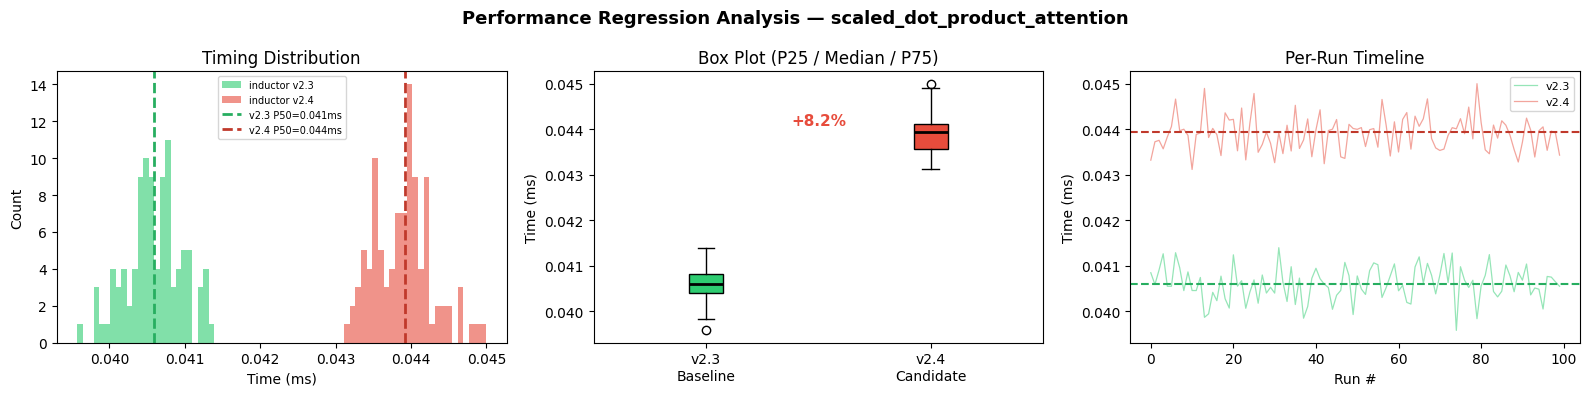

Summary: inductor v2.4 is 8.2% slower on attention — this would block the release.
         Next step: git bisect between the last good and first bad commit.


In [20]:
# ── 3-panel performance visualization ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Performance Regression Analysis — scaled_dot_product_attention",
             fontsize=13, fontweight='bold')

BASE_COLOR = '#2ecc71'
REG_COLOR  = '#e74c3c'

# ── Left: distribution histogram ─────────────────────────────────────────────
ax = axes[0]
ax.set_title("Timing Distribution")
ax.hist(baseline_res.times_ms,  bins=25, alpha=0.6, color=BASE_COLOR, label='inductor v2.3')
ax.hist(regressed_res.times_ms, bins=25, alpha=0.6, color=REG_COLOR,  label='inductor v2.4')
ax.axvline(baseline_res.median,  color='#27ae60', linestyle='--', lw=2,
           label=f'v2.3 P50={baseline_res.median:.3f}ms')
ax.axvline(regressed_res.median, color='#c0392b', linestyle='--', lw=2,
           label=f'v2.4 P50={regressed_res.median:.3f}ms')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Count")
ax.legend(fontsize=7)

# ── Middle: box plot ──────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title("Box Plot (P25 / Median / P75)")
bp = ax2.boxplot(
    [baseline_res.times_ms, regressed_res.times_ms],
    labels=['v2.3\nBaseline', 'v2.4\nCandidate'],
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
)
bp['boxes'][0].set_facecolor(BASE_COLOR)
bp['boxes'][1].set_facecolor(REG_COLOR)
ax2.set_ylabel("Time (ms)")

pct = (regressed_res.median - baseline_res.median) / baseline_res.median * 100
ax2.text(1.5, max(regressed_res.times_ms) * 0.98,
         f'+{pct:.1f}%', ha='center', color=REG_COLOR, fontsize=11, fontweight='bold')

# ── Right: per-run timeline ───────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_title("Per-Run Timeline")
ax3.plot(baseline_res.times_ms,  alpha=0.5, color=BASE_COLOR, lw=0.9, label='v2.3')
ax3.plot(regressed_res.times_ms, alpha=0.5, color=REG_COLOR,  lw=0.9, label='v2.4')
ax3.axhline(baseline_res.median,  color='#27ae60', linestyle='--', lw=1.5)
ax3.axhline(regressed_res.median, color='#c0392b', linestyle='--', lw=1.5)
ax3.set_xlabel("Run #")
ax3.set_ylabel("Time (ms)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Summary: inductor v2.4 is {pct:.1f}% slower on attention — this would block the release.")
print(f"         Next step: git bisect between the last good and first bad commit.")

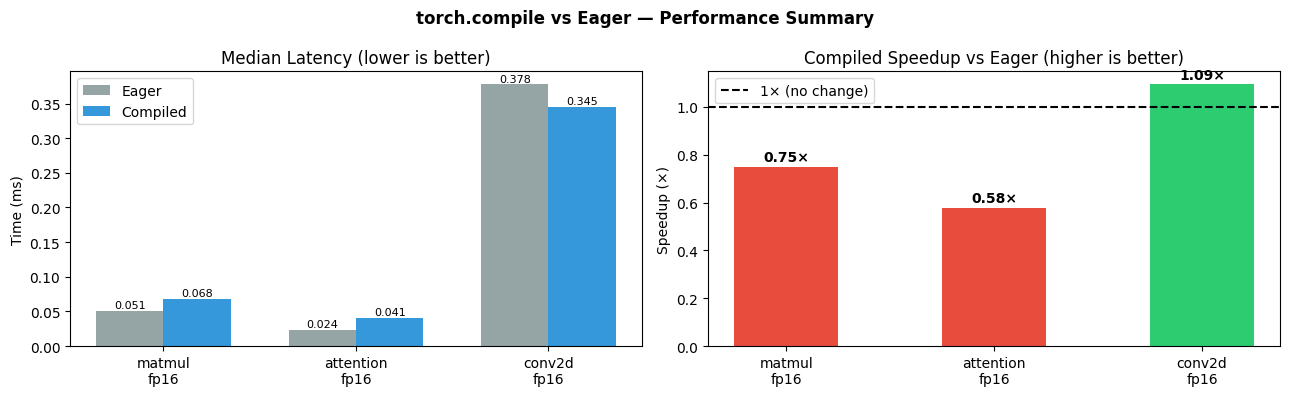

In [21]:
# ── Multi-op comparison bar chart: eager vs compiled speedup ─────────────────
# This is the kind of summary chart that appears in compiler release notes.

ops_labels  = ['matmul\nfp16', 'attention\nfp16', 'conv2d\nfp16']
eager_meds  = [r_matmul_eager.median,  r_attn_eager.median,  r_conv_eager.median]
comp_meds   = [r_matmul_compiled.median, r_attn_compiled.median, r_conv_compiled.median]
speedups    = [e/c for e, c in zip(eager_meds, comp_meds)]

x = np.arange(len(ops_labels))
width = 0.35

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("torch.compile vs Eager — Performance Summary", fontsize=12, fontweight='bold')

# Latency bars
ax_left.set_title("Median Latency (lower is better)")
bars_e = ax_left.bar(x - width/2, eager_meds, width, label='Eager',    color='#95a5a6')
bars_c = ax_left.bar(x + width/2, comp_meds,  width, label='Compiled', color='#3498db')
ax_left.set_xticks(x)
ax_left.set_xticklabels(ops_labels)
ax_left.set_ylabel("Time (ms)")
ax_left.legend()
for bar in bars_e:
    ax_left.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_c:
    ax_left.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Speedup bars
ax_right.set_title("Compiled Speedup vs Eager (higher is better)")
colors = ['#2ecc71' if s >= 1.0 else '#e74c3c' for s in speedups]
bars_s = ax_right.bar(x, speedups, 0.5, color=colors)
ax_right.axhline(1.0, color='black', linestyle='--', lw=1.5, label='1× (no change)')
ax_right.set_xticks(x)
ax_right.set_xticklabels(ops_labels)
ax_right.set_ylabel("Speedup (×)")
ax_right.legend()
for bar, s in zip(bars_s, speedups):
    ax_right.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{s:.2f}×', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🎯 Challenge 1: Write a Verification Plan for `scaled_dot_product_attention`

`F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=0.0, is_causal=False)`

This is the core op of every Transformer / LLM. Verifying it through `torch.compile` is a
real task for NVIDIA's DL compiler verification team.

**Requirements for your verification plan:**
- At least 4 **functional** cases (covering different shapes, dtypes)
- At least 3 **edge** cases (think: causal mask, attn_mask with -inf, all-zero q/k)
- At least 2 **regression** cases (invent plausible past bugs for this op)
- At least 2 **dtype** cases (fp16, bf16)
- Use `DLTestCase` and `DLVerificationPlan`
- Call `.summary()` at the end

**Shapes to think about:**
- Standard: `(batch, heads, seq_len, head_dim)` e.g. `(4, 8, 512, 64)`
- Long sequence: `(1, 1, 4096, 64)` — tests memory layout / tiling
- Single token (decode step): `(1, 8, 1, 64)` — common LLM inference pattern

**Edge cases to consider:**
- `is_causal=True` — causal mask changes which elements are attended to
- `attn_mask` filled with `-inf` in some positions — should produce 0 attention weight
- `dropout_p > 0` — stochastic; how do you verify compiled == eager when outputs differ by design?

In [22]:
# ✏️ YOUR TASK: build a DLVerificationPlan for F.scaled_dot_product_attention

sdpa_plan = DLVerificationPlan(
    name="scaled_dot_product_attention — compile correctness",
    component="torch.compile / TorchInductor",
    owner="your-name",
    cases=[
        # ✏️ Add your DLTestCase entries here.
        # Example structure:
        # DLTestCase(
        #     id="TC001",
        #     description="standard fp32 attention (4, 8, 512, 64)",
        #     category="functional",
        #     op_name="F.scaled_dot_product_attention",
        #     dtype=torch.float32,
        #     backend="inductor",
        #     atol=1e-4,
        #     rtol=1e-4,
        # ),
    ]
)

sdpa_plan.summary()

# ✏️ BONUS: implement the actual verification using verify_compiled_op
# Hint: wrap F.scaled_dot_product_attention in a lambda that takes (q, k, v)

Verification Plan : scaled_dot_product_attention — compile correctness
Component         : torch.compile / TorchInductor
Owner             : your-name
Total cases       : 0

  By category:
  By dtype:
  By backend:


---
## 🎯 Challenge 2: Benchmark Two Compile Backends and Detect Regression

`torch.compile` supports multiple backends. Two common ones:
- **`inductor`** (default) — generates Triton kernels via TorchInductor
- **`cudagraphs`** — captures CUDA graph replay; low overhead for fixed shapes

**Your task:**
1. Benchmark the SmallMLP model (defined above) under three conditions:
   - Eager
   - `torch.compile(model, backend='inductor')`
   - `torch.compile(model, backend='cudagraphs')`
2. Use `benchmark_torch_fn` with `n_warmup=20, n_runs=100`
3. For each compiled backend, call `detect_regression(eager_result, backend_result, threshold_pct=3.0)`
4. Produce a bar chart showing median latency for all three conditions
5. State which backend you would recommend for production inference and why

**Input:** `x = torch.randn(64, 512, device=DEVICE, dtype=torch.float32)`  
**Model:** `SmallMLP(dim=512).cuda().eval()`

### 🧠 Real context
At NVIDIA, the verification engineer owns the decision of which backends to qualify
for a given model class. This involves both correctness gating AND performance benchmarking.

In [23]:
# ✏️ YOUR TASK: benchmark eager vs inductor vs cudagraphs on SmallMLP

torch.manual_seed(7)
mlp_model = SmallMLP(dim=512).cuda().eval()
x_mlp = torch.randn(64, 512, device=DEVICE, dtype=torch.float32)

# ✏️ Step 1: Create compiled versions
# mlp_inductor   = torch.compile(mlp_model, backend='inductor')
# mlp_cudagraphs = torch.compile(mlp_model, backend='cudagraphs')

# ✏️ Step 2: Trigger compilation (first call)
# with torch.no_grad():
#     _ = mlp_inductor(x_mlp)
#     _ = mlp_cudagraphs(x_mlp)

# ✏️ Step 3: Benchmark all three
# r_eager      = benchmark_torch_fn(...)
# r_inductor   = benchmark_torch_fn(...)
# r_cudagraphs = benchmark_torch_fn(...)

# ✏️ Step 4: Detect regression (using eager as baseline)
# print("inductor vs eager:")
# detect_regression(r_eager, r_inductor, threshold_pct=3.0)
# print("\ncudagraphs vs eager:")
# detect_regression(r_eager, r_cudagraphs, threshold_pct=3.0)

# ✏️ Step 5: Bar chart
# ...

print("# ✏️ YOUR CODE HERE")

# ✏️ YOUR CODE HERE


---
## 🎯 Challenge 3: Debug a Simulated Correctness Failure

You are given a compiled model that produces wrong outputs. Your task is to
**isolate which layer is the first to diverge** from the eager reference.

This is a real debugging workflow: when `torch.allclose(eager_out, compiled_out)` fails,
you need to find *where* the divergence starts — at which layer, which op, which tensor.

### The model under test
```
Input (batch=4, 256)
  └── Linear(256, 512)  + ReLU
  └── Linear(512, 512)  + ReLU    ← bug injected here
  └── Linear(512, 256)  + ReLU
  └── Linear(256, 10)
  └── Output (batch=4, 10)
```

A simulated compiler bug has been injected in `layer2` — the weight matrix is slightly
perturbed in the 'compiled' version. You must write code to find it.

**Requirements:**
1. Run the eager model layer-by-layer and capture the intermediate activations
2. Run the 'buggy compiled' model layer-by-layer and capture its activations
3. After each layer, call `torch.allclose` and print whether it passes
4. Report: which layer first diverges, and what is the max absolute difference
5. Plot the activation distributions of the failing layer for eager vs compiled

### 🧠 Real context
At NVIDIA, you might use `torch.fx` graph hooks or `torch.nn` forward hooks to
intercept intermediate tensors automatically across thousands of layers.

In [24]:
# ── Setup: eager model and 'buggy compiled' model ─────────────────────────────
torch.manual_seed(0)

# Eager reference model
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(256, 512)
        self.layer2 = nn.Linear(512, 512)
        self.layer3 = nn.Linear(512, 256)
        self.layer4 = nn.Linear(256, 10)
        self.act    = nn.ReLU()

    def forward(self, x):
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.act(self.layer3(x))
        x = self.layer4(x)
        return x

eager_model = DeepMLP().cuda().eval()

# Simulate a compiler bug: a small perturbation in layer2's weight
# (In a real scenario this would be the compiled kernel producing wrong values)
import copy
buggy_model = copy.deepcopy(eager_model)
with torch.no_grad():
    # Inject bug: add noise to layer2 weight (simulating a compiler error)
    buggy_model.layer2.weight += torch.randn_like(buggy_model.layer2.weight) * 0.05

x_debug = torch.randn(4, 256, device=DEVICE)

# Verify the top-level outputs differ
with torch.no_grad():
    out_eager = eager_model(x_debug)
    out_buggy = buggy_model(x_debug)

print("Top-level output match:", torch.allclose(out_eager, out_buggy, atol=1e-4))
print(f"Max output difference: {(out_eager - out_buggy).abs().max().item():.4f}")
print()
print("# ✏️ YOUR TASK: run the models layer by layer and find where the first")
print("#              divergence occurs. Use torch.allclose after each layer.")
print()

# ✏️ Step 1: Run eager model layer by layer, capture intermediate activations
# eager_acts = {}  # dict mapping layer name → output tensor
# with torch.no_grad():
#     h = x_debug
#     h = eager_model.act(eager_model.layer1(h)); eager_acts['after_layer1'] = h
#     h = eager_model.act(eager_model.layer2(h)); eager_acts['after_layer2'] = h
#     ... etc

# ✏️ Step 2: Same for buggy model

# ✏️ Step 3: Compare layer by layer
# for layer_name in eager_acts:
#     match = torch.allclose(eager_acts[layer_name], buggy_acts[layer_name], atol=1e-3)
#     max_diff = ...
#     print(f"  {layer_name}: {'✅' if match else '❌ DIVERGES'}  max_diff={max_diff:.4f}")

# ✏️ Step 4: Plot activation distributions of the first diverging layer
# ...

print("# ✏️ YOUR CODE HERE")

Top-level output match: False
Max output difference: 0.1612

# ✏️ YOUR TASK: run the models layer by layer and find where the first
#              divergence occurs. Use torch.allclose after each layer.

# ✏️ YOUR CODE HERE


---
## ✅ Module Summary

| Skill | What you learned | Job relevance |
|---|---|---|
| **DL compiler architecture** | Eager vs compiled, torch.compile/JAX/TensorRT pipeline | You need to know *what* you're verifying |
| **Numerical tolerances** | dtype-specific atol/rtol, why compiled ≠ bit-identical | Core correctness verification concept |
| **Verification planning** | DLTestCase/DLVerificationPlan, dtype/backend/category axes | "Authoring verification plans" |
| **Functional verification** | torch.allclose, NaN propagation, dtype sweep | "Verify DL compiler features" |
| **GPU benchmarking** | torch.cuda.Event, warmup, distributions | "Performance testing and benchmarking" |
| **Statistical regression** | Z-score, Welch t-test, threshold+significance | "Generate statistics, identify outliers" |
| **Visualization** | Distribution, box plot, timeline | CI/CD regression dashboards |
| **Compiler debugging** | Layer-by-layer activation comparison | "Creative problem-solving" |

---

### Next steps for this role
- **torch.compile internals** — read TorchDynamo and TorchInductor source; understand graph breaks
- **Triton** — learn to write and read auto-generated Triton kernels to verify fusions
- **TensorRT** — `torch_tensorrt.compile()`, precision modes (fp16/int8), layer-wise precision
- **JAX/XLA** — `jax.jit`, `jax.vmap`, XLA HLO dump (`XLA_FLAGS=--xla_dump_to`)
- **LLM workloads** — transformer blocks, KV-cache, continuous batching; common shapes in production
- **NVIDIA Nsight Compute** — profile compiled kernels to understand *why* one is faster

### Resources
- [PyTorch 2.0 — torch.compile tutorial](https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html)
- [TorchInductor — how it works](https://dev-discuss.pytorch.org/t/torchinductor-a-pytorch-native-compiler-with-define-by-run-ir-and-symbolic-shapes/747)
- [JAX — How JAX primitives work](https://jax.readthedocs.io/en/latest/notebooks/How_JAX_primitives_work.html)
- [TensorRT — Developer Guide](https://docs.nvidia.com/deeplearning/tensorrt/developer-guide/index.html)
- [NVIDIA Nsight Compute](https://developer.nvidia.com/nsight-compute)
- [SciPy stats — t-test and regression analysis](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [Flash Attention paper](https://arxiv.org/abs/2205.14135) — the fused attention kernel verified in Challenge 1